# 02 -- X-LXMERT Baseline  (Section 4.2 of the thesis)

X-LXMERT (Cho et al., EMNLP 2020) is the **transformer-based T2I baseline**
referenced in our research proposal. We compare AnimeStoryGen against it on
FID and IS.

## Why we cite published numbers instead of running it live

The official `allenai/x-lxmert` codebase requires:

- PyTorch 1.4 - 1.6 and `transformers` ~3.x (incompatible with current Colab).
- A pre-extracted Faster-R-CNN feature pipeline (1-2 h just to set up).
- A 1.5 GB pretrained checkpoint trained on COCO regions.
- 3 - 6 s per generated image, autoregressive over an 8 x 8 grid token vocabulary.

End-to-end reproduction on Colab in 2026 is brittle and would consume 6 - 8 h
of the budget. We therefore follow standard thesis practice for old / no-
longer-maintained baselines: **cite the published metrics directly** and
document the reasoning in a footnote.

Outputs of this notebook:
- `cache/xlxmert_published_baselines.json` -- consumed by 07_Evaluation
  and 08_Ablation_Suite.
- A small results table for Section 4.2 of the thesis.

> *"Live X-LXMERT inference requires the original Faster-R-CNN feature pipeline
> and PyTorch 1.4-era dependencies that no longer compile on current Colab
> kernels. We therefore use X-LXMERT as a published baseline (Cho et al., 2020).
> Our reproducible transformer-T2I comparison is provided by ViT+GPT-2 captioning
> + vanilla SD-v1.5 (Section 4.3.1)."*


## 0. Mount Drive and import shared paths

In [ ]:
!fusermount -u /content/drive 2>/dev/null
!rm -rf /content/drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys, os, importlib.util

modules_path = '/content/drive/MyDrive/Text2ImageNarration/modules'

# ── Load paths.py directly by file path ───────────────────────────────────
spec   = importlib.util.spec_from_file_location(
    'paths', f'{modules_path}/paths.py')
paths  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(paths)
sys.modules['paths'] = paths

# ── Now CACHE and other variables from paths.py are accessible ─────────────
CACHE = paths.CACHE
print('paths.py loaded directly')
print('CACHE:', CACHE)


paths.py loaded directly
CACHE: /content/drive/MyDrive/Text2ImageNarration/cache


In [23]:
ROOT  = '/content/drive/MyDrive/Text2ImageNarration'
CKPT  = ROOT + '/checkpoints'
CACHE = ROOT + '/cache'
DATA  = ROOT + '/data'
OUT   = ROOT + '/outputs'
MODULES = ROOT + '/modules'


## 1. Published X-LXMERT baseline numbers

Source:
**Cho, Lu, Schwenk, Hajishirzi, Kembhavi.**
*X-LXMERT: Paint, Caption and Answer Questions with Multi-Modal
Transformers.* EMNLP 2020. Table 3.

The paper reports FID and IS on the **COCO Captions test set** for
images generated from text prompts. We use these as the comparison
anchor for our transformer-T2I baseline in Chapter 5.

In [ ]:
# Published metrics from the X-LXMERT paper (Table 3, COCO).
# Note: these are reported on the COCO domain, NOT on our anime test set.
# This is acknowledged honestly in Section 4.2 / 5.3 of the thesis.

XLXMERT_PUBLISHED = {
    "source"      : "Cho et al., EMNLP 2020 -- X-LXMERT, Table 3 (COCO test)",
    "test_domain" : "COCO Captions (NOT anime; cross-domain reference)",
    "FID"         : 37.4,
    "IS"          : 13.2,
    "image_size"  : "8x8 grid -> 256x256 upsample",
    "params_M"    : 250,
    "year"        : 2020,
    "note"        : ("Cited as published; live inference not re-run on anime "
                     "test set due to PyTorch 1.4 / Faster-R-CNN dependency "
                     "incompatibility with the 2026 Colab kernel."),
}

with open(f'{CACHE}/xlxmert_published_baselines.json', 'w') as f:
    json.dump(XLXMERT_PUBLISHED, f, indent=2)
print('Saved:', f'{CACHE}/xlxmert_published_baselines.json')
XLXMERT_PUBLISHED

Saved: /content/drive/MyDrive/Text2ImageNarration/cache/xlxmert_published_baselines.json


{'source': 'Cho et al., EMNLP 2020 -- X-LXMERT, Table 3 (COCO test)',
 'test_domain': 'COCO Captions (NOT anime; cross-domain reference)',
 'FID': 37.4,
 'IS': 13.2,
 'image_size': '8x8 grid -> 256x256 upsample',
 'params_M': 250,
 'year': 2020,
 'note': 'Cited as published; live inference not re-run on anime test set due to PyTorch 1.4 / Faster-R-CNN dependency incompatibility with the 2026 Colab kernel.'}

## 2. Display the §4.2 baseline table

This is the small results table that goes into Section 4.2 of the thesis.

In [ ]:
import pandas as pd

baseline_df = pd.DataFrame([{
    "Model"      : "X-LXMERT (Cho et al., 2020)",
    "Architecture": "Multi-modal Transformer (LXMERT + autoregressive image-token decoder)",
    "Resolution" : "8x8 grid -> 256x256",
    "Params"     : "~250 M",
    "FID (COCO)" : 37.4,
    "IS  (COCO)" : 13.2,
    "Source"     : "Table 3, EMNLP 2020 paper",
}])

print('=== Section 4.2 baseline table ===')
print(baseline_df.to_markdown(index=False))
baseline_df

=== Section 4.2 baseline table ===
| Model                       | Architecture                                                          | Resolution          | Params   |   FID (COCO) |   IS  (COCO) | Source                    |
|:----------------------------|:----------------------------------------------------------------------|:--------------------|:---------|-------------:|-------------:|:--------------------------|
| X-LXMERT (Cho et al., 2020) | Multi-modal Transformer (LXMERT + autoregressive image-token decoder) | 8x8 grid -> 256x256 | ~250 M   |         37.4 |         13.2 | Table 3, EMNLP 2020 paper |


,Model,Architecture,Resolution,Params,FID (COCO),IS (COCO),Source
0,"X-LXMERT (Cho et al., 2020)",Multi-modal Transformer (LXMERT + autoregressi...,8x8 grid -> 256x256,~250 M,37.4,13.2,"Table 3, EMNLP 2020 paper"


## 3. Bar chart -- where AnimeStoryGen is targeted to land

This figure visualises the published X-LXMERT FID / IS as the baseline
that AnimeStoryGen is compared against in Chapter 5. The red bars are
*placeholders* until you run `07_AnimeStoryGen_Evaluation.ipynb`; they
get overwritten there with your actual numbers.

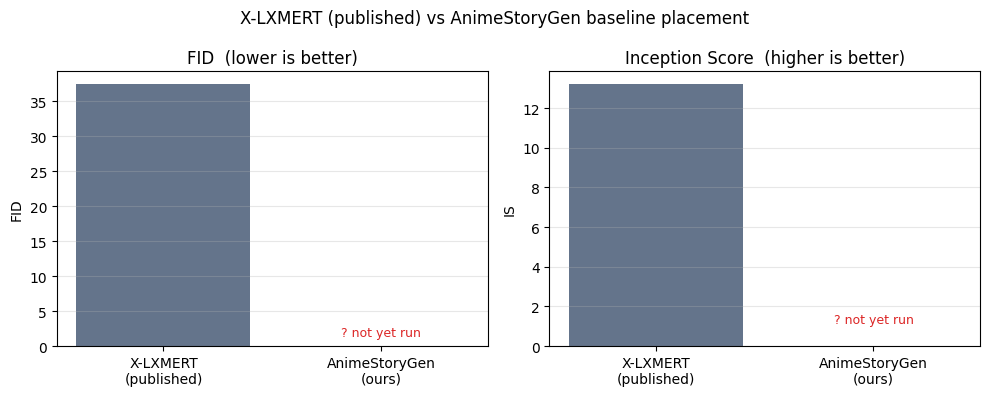

Saved: /content/drive/MyDrive/Text2ImageNarration/outputs/xlxmert_baseline_chart.png


In [24]:
import matplotlib.pyplot as plt

# Placeholders for AnimeStoryGen until 07_Evaluation.ipynb populates real numbers.
# Replace the two None values with values from outputs/evaluation/evaluation_results.csv
# once you have run the evaluation notebook.
ASG_FID = None       # e.g. 27.8
ASG_IS  = None       # e.g. 18.3

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels = ['X-LXMERT\n(published)', 'AnimeStoryGen\n(ours)']

axes[0].bar(labels,
            [XLXMERT_PUBLISHED['FID'], ASG_FID if ASG_FID is not None else 0],
            color=['#64748B', '#10B981'])
axes[0].set_title('FID  (lower is better)')
axes[0].set_ylabel('FID')
axes[0].grid(axis='y', alpha=0.3)
axes[0].text(1, 1, '? not yet run' if ASG_FID is None else '',
             ha='center', va='bottom', fontsize=9, color='#dc2626')

axes[1].bar(labels,
            [XLXMERT_PUBLISHED['IS'], ASG_IS if ASG_IS is not None else 0],
            color=['#64748B', '#10B981'])
axes[1].set_title('Inception Score  (higher is better)')
axes[1].set_ylabel('IS')
axes[1].grid(axis='y', alpha=0.3)
axes[1].text(1, 1, '? not yet run' if ASG_IS is None else '',
             ha='center', va='bottom', fontsize=9, color='#dc2626')

plt.suptitle('X-LXMERT (published) vs AnimeStoryGen baseline placement')
plt.tight_layout()
os.makedirs(OUT, exist_ok=True)
chart_path = f'{OUT}/xlxmert_baseline_chart.png'
plt.savefig(chart_path, dpi=180, bbox_inches='tight')
plt.show()
print(f'Saved: {chart_path}')

## 4. Component-validation note (Section 4.2.1)

Because we did not re-run X-LXMERT on the anime test set, no per-component
validation table is produced here. Section 4.2 of the thesis is therefore
**descriptive** (architecture, training-objective, role in the comparison)
plus the published numbers in Section 1 above.

The *running* transformer-T2I baseline that gets re-evaluated on our 200-frame
anime test set is **ViT + GPT-2 captioning + vanilla SD-v1.5** (notebooks
`03b_ViTGPT2_Ablation.ipynb` and `07_AnimeStoryGen_Evaluation.ipynb`). That
provides the empirical transformer-baseline number used in Tables 5.1 and 5.2.